# dk_lvm_tools

## QuickStart Guide (20250601)

This is a quick start guide to using some initial custom LVM visualization tools from DK with help from Ethan Driscoll. 
This is a work in progress, and will be updated frequently over this summer at [https://github.com/Deech08/dk_lvm_tools](https://github.com/Deech08/dk_lvm_tools)


The primary code base is enclosed in a class 'dk_lvm_tools.dap'

It can be used to load DAP fits files direclty (following a SAS directory structure) or load a pre-compiled astropy table of DAP results (which DK can share if needed, though note it is ~16GB and when loading often balloons up in RAM - up to 80GB for me). 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import astropy.units as u
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm, Normalize

%matplotlib ipympl

# import dap
from dk_lvm_tools import dap


In [2]:
# Load pre-compiled fits Table
# This can take a bit... ~20 seconds for me, could be longer



compiled_filename = "../Data/DAP_Table_v1.2.1_lite_flux_vel.fits"
lvm = dap(filename = compiled_filename)

In [3]:
#This views as a standard astropy Table
lvm

id,ra,dec,mask,fiberid,exposure,flux_[OII]_3726.03,e_flux_[OII]_3726.03,vel_[OII]_3726.03,e_vel_[OII]_3726.03,flux_[OII]_3728.82,e_flux_[OII]_3728.82,vel_[OII]_3728.82,e_vel_[OII]_3728.82,flux_Hepsilon_3970.07,e_flux_Hepsilon_3970.07,vel_Hepsilon_3970.07,e_vel_Hepsilon_3970.07,flux_Hdelta_4101.77,e_flux_Hdelta_4101.77,vel_Hdelta_4101.77,e_vel_Hdelta_4101.77,flux_Hgamma_4340.49,e_flux_Hgamma_4340.49,vel_Hgamma_4340.49,e_vel_Hgamma_4340.49,flux_Hbeta_4861.36,e_flux_Hbeta_4861.36,vel_Hbeta_4861.36,e_vel_Hbeta_4861.36,flux_[OIII]_5006.84,e_flux_[OIII]_5006.84,vel_[OIII]_5006.84,e_vel_[OIII]_5006.84,flux_[OI]_5577.34,e_flux_[OI]_5577.34,vel_[OI]_5577.34,e_vel_[OI]_5577.34,flux_[NII]_5754.59,e_flux_[NII]_5754.59,vel_[NII]_5754.59,e_vel_[NII]_5754.59,flux_[OI]_6300.3,e_flux_[OI]_6300.3,vel_[OI]_6300.3,e_vel_[OI]_6300.3,flux_[SIII]_6312.06,e_flux_[SIII]_6312.06,vel_[SIII]_6312.06,e_vel_[SIII]_6312.06,flux_[NII]_6548.05,e_flux_[NII]_6548.05,vel_[NII]_6548.05,e_vel_[NII]_6548.05,flux_Halpha_6562.85,e_flux_Halpha_6562.85,vel_Halpha_6562.85,e_vel_Halpha_6562.85,flux_[NII]_6583.45,e_flux_[NII]_6583.45,vel_[NII]_6583.45,e_vel_[NII]_6583.45,flux_[SII]_6716.44,e_flux_[SII]_6716.44,vel_[SII]_6716.44,e_vel_[SII]_6716.44,flux_[SII]_6730.82,e_flux_[SII]_6730.82,vel_[SII]_6730.82,e_vel_[SII]_6730.82,flux_[SIII]_9531.1,e_flux_[SIII]_9531.1,vel_[SIII]_9531.1,e_vel_[SIII]_9531.1,GAL-LON,GAL-LAT
,deg,deg,,,,lvm_flux,lvm_flux,km / s,km / s,lvm_flux,lvm_flux,km / s,km / s,lvm_flux,lvm_flux,km / s,km / s,lvm_flux,lvm_flux,km / s,km / s,lvm_flux,lvm_flux,km / s,km / s,lvm_flux,lvm_flux,km / s,km / s,lvm_flux,lvm_flux,km / s,km / s,lvm_flux,lvm_flux,km / s,km / s,lvm_flux,lvm_flux,km / s,km / s,lvm_flux,lvm_flux,km / s,km / s,lvm_flux,lvm_flux,km / s,km / s,lvm_flux,lvm_flux,km / s,km / s,lvm_flux,lvm_flux,km / s,km / s,lvm_flux,lvm_flux,km / s,km / s,lvm_flux,lvm_flux,km / s,km / s,lvm_flux,lvm_flux,km / s,km / s,lvm_flux,lvm_flux,km / s,km / s,deg,deg
bytes10,float64,float64,bool,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
13292.10,148.6508674779044,-53.631816659940974,True,10,13292,443.58516905809967,118.7152077819953,10.365977296266706,290946.0227882002,-85.66148389423937,146.96857970804678,17.337248615080632,191315.39097364832,54.19070114032656,109.06625318077646,10.472174085153545,70803.20140990573,60.391075404602745,137.87380664879413,-83.67530276927404,25905.544815433303,-61.00306281873678,70.23112686252001,11.852281257346728,37528.871099201424,-234.0011341981718,53.96266466740304,-17.122611663185054,20953.65069471597,-31.521175754408215,57.31465198911778,-67.42542295339297,18237.77500990677,-2529.3846657762047,52.96108116481774,-3.7208065331759803,18467.986431710444,-42.495139612042244,57.6074031687607,-22.439707182173994,26934.37766909751,-5548.545418554248,68.46591298283855,-2.53693974451646,31990.177932407383,30.24831673363432,462.07013810680826,-27.844314577801747,431575.99721475685,-11.373809332718782,49.331274305594974,4.631117245103312,22252.147623287343,482.75799722343874,30.20250257729342,-3.6594305971736825,13512.542211104239,128.1719110585049,34.63750739496436,4.5662574851620485,11461.439155254408,154.01198667349638,23.238059541471518,-9.270427432651383,6384.908274751746,127.74310019852393,39.80218131616734,-5.698740017187692,3895.331474438717,318.94665561860376,129.36766145387608,-23.31916567916087,27136.819866654674,278.50774648826456,0.6369602957022592
13292.100,148.60808556332532,-53.59201714726013,True,100,13292,8

### Convenience functions

In [4]:
# In inherits all class methods from astropy.table.Table and inclused some extras from me
dir(lvm)

['Column',
 'ColumnClass',
 'MaskedColumn',
 'Row',
 'TableColumns',
 'TableFormatter',
 '__array__',
 '__bytes__',
 '__class__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__get_item__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setitem__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_base_repr_',
 '_check_names_dtype',
 '_column_class',
 '_convert_col_for_table',
 '_convert_data_to_col',
 '_convert_string_dtype',
 '_copy_indices',
 '_first_colname',
 '_get_col_cls_for_table',
 '_init_from_cols',
 '_init_from_dict',
 '_init_from_list',
 '_init_from_list_of_dicts',
 '_init_from_ndarray',
 '_init_indices',
 '_ipython_key_comple

In [5]:
lvm.colnames

['id',
 'ra',
 'dec',
 'mask',
 'fiberid',
 'exposure',
 'flux_[OII]_3726.03',
 'e_flux_[OII]_3726.03',
 'vel_[OII]_3726.03',
 'e_vel_[OII]_3726.03',
 'flux_[OII]_3728.82',
 'e_flux_[OII]_3728.82',
 'vel_[OII]_3728.82',
 'e_vel_[OII]_3728.82',
 'flux_Hepsilon_3970.07',
 'e_flux_Hepsilon_3970.07',
 'vel_Hepsilon_3970.07',
 'e_vel_Hepsilon_3970.07',
 'flux_Hdelta_4101.77',
 'e_flux_Hdelta_4101.77',
 'vel_Hdelta_4101.77',
 'e_vel_Hdelta_4101.77',
 'flux_Hgamma_4340.49',
 'e_flux_Hgamma_4340.49',
 'vel_Hgamma_4340.49',
 'e_vel_Hgamma_4340.49',
 'flux_Hbeta_4861.36',
 'e_flux_Hbeta_4861.36',
 'vel_Hbeta_4861.36',
 'e_vel_Hbeta_4861.36',
 'flux_[OIII]_5006.84',
 'e_flux_[OIII]_5006.84',
 'vel_[OIII]_5006.84',
 'e_vel_[OIII]_5006.84',
 'flux_[OI]_5577.34',
 'e_flux_[OI]_5577.34',
 'vel_[OI]_5577.34',
 'e_vel_[OI]_5577.34',
 'flux_[NII]_5754.59',
 'e_flux_[NII]_5754.59',
 'vel_[NII]_5754.59',
 'e_vel_[NII]_5754.59',
 'flux_[OI]_6300.3',
 'e_flux_[OI]_6300.3',
 'vel_[OI]_6300.3',
 'e_vel_[OI]_6

In [6]:
# Access a single column
lvm["flux_Halpha_6562.85"]

482.75799722343874
357.2275396205338
327.81003484976003
277.48005638482675
348.9917318571665
375.07630196506125
380.352421341379
401.923892147226
375.13683518498425
384.6398883765248
337.2861222954019


Flux has an internal unit of u.lvm_flux which represents a value based on the energy per second per cm^2 per fiber converted to standard units - 

In [7]:
lvm["flux_Halpha_6562.85"].unit.represents

Unit("2.55447e-20 erg / (s arcsec2 cm2)")

If you need photon flux units instead of energy flux units you can convert quickly:

In [8]:
help(lvm.convert_flux_to_rayleigh)

Help on method convert_flux_to_rayleigh in module dk_lvm_tools.dapTableMixin:

convert_flux_to_rayleigh(colname) method of dk_lvm_tools.dap.dap instance
    Converts specified column of flux values to photon units from energy units

    Parameters
    ----------
    colname: 'str'
            name of column to convert flux values of



In [9]:
halpha_rayleighs = lvm.convert_flux_to_rayleigh("flux_Halpha_6562.85")
halpha_rayleighs

<Quantity [ 2.17824171,  1.6118385 ,  1.47910443, ..., 15.15113324,
           15.91046157, 15.36424229] R>

### Masked Data - SNR

You can mask flux by signal to noise thresholds of your choice (default of SNR >3 if unspecified for most commands)

In [10]:
ha_masked = lvm.get_snr_masked_intensity("flux_Halpha_6562.85", 
                                         snr_cut = 3, #default value is also 3, so only need to specifiy if you want a different amount
                                         rayleigh = True, # converts to rayleighs or set False to have in energy units
                                        )
ha_masked

masked_Quantity(data=[2.1782417087670387, 1.6118385004433793,
                      1.47910442616994, ..., 15.151133242689518,
                      15.910461566186596, 15.364242293479203],
                mask=[False, False, False, ..., False, False, False],
          fill_value=1e+20)

In [11]:
ha_masked.data.unit

Unit("R")

### Line Ratios

In [12]:
nii_ha = lvm.get_line_ratio(
    "flux_Halpha_6562.85", 
    "flux_[NII]_6583.45",
    rayleigh = True, # if want in photon units
    snr_cut = 5, # higher than default SNR cut
)

In [13]:
nii_ha

masked_Quantity(data=[--, --, --, ..., 2.838256908601244,
                      2.8141951521171173, 2.568160121786636],
                mask=[ True,  True,  True, ..., False, False, False],
          fill_value=1e+20)

## Quick Plots

### Histograms

In [14]:
fig = lvm.plot_histogram?

Signature:
lvm.plot_histogram(
    x,
    y=None,
    ax=None,
    fig=None,
    snr_cut=3,
    data_mask=None,
    label_axes=True,
    log_scale=False,
    rayleigh=False,
    **kwargs,
)
Docstring:
Uses Seaborns displot on columns of table

Parameters
----------
x: 'str'
        name of x-axis column to consider
y: 'str'
        name of y-axis column to consider
data_mask: 'list-like'
        custom masking array to apply to data
snr_cut: 'float'
        SNR to cut data by set to 0 to not use SNR info (for velocities, etc.)
data_mask: 'np.array'
        mask to use on the specified columns
label_axes: 'bool'
        if True, adds x and y axis labels
log_scale: 'bool', list-like
        if True, will log scale x values
        if 2 len list-like, will apply log scale to x and/or y axis [x, y]
rayleigh: 'bool':
        if True, convert intensity to Rayleigh - only for flux!
kwargs:
        passed to ax.hexbin 
File:      ~/repos/dk_lvm_tools/dk_lvm_tools/dapTableMixin.py
Type:      me

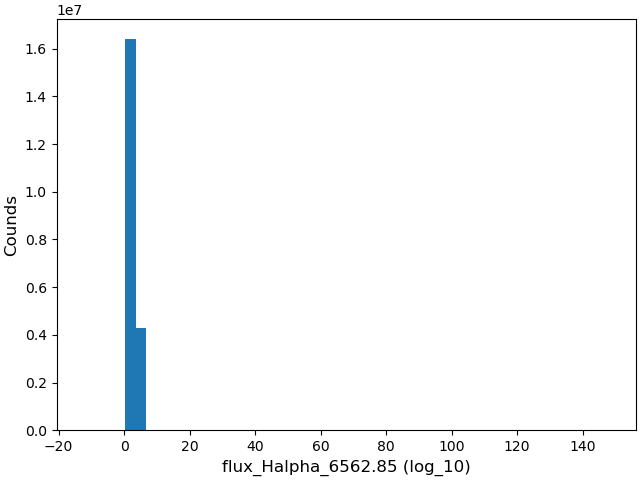

In [15]:
fig = lvm.plot_histogram("flux_Halpha_6562.85", log_scale = True)

Chances are a histogram of all the data will span too large a range - cut to a smaller range - or smaller map

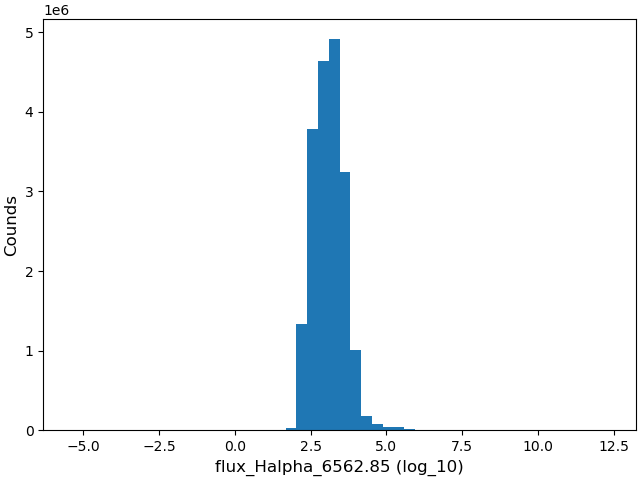

In [16]:
flux_mask = halpha_rayleighs < 1e10 * u.R
flux_mask &= halpha_rayleighs > 1e-10*u.R

fig = lvm.plot_histogram("flux_Halpha_6562.85", data_mask = flux_mask, snr_cut = 5, log_scale = True)

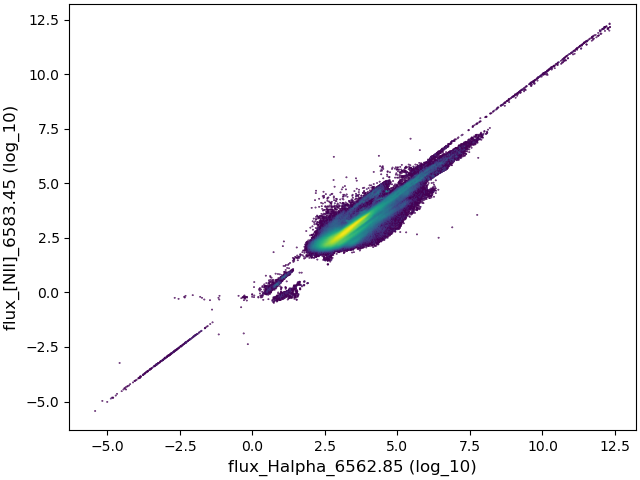

In [17]:
flux_mask = halpha_rayleighs < 1e10 * u.R
flux_mask &= halpha_rayleighs > 1e-10*u.R

fig = lvm.plot_histogram("flux_Halpha_6562.85", 
                          "flux_[NII]_6583.45",
                         data_mask = flux_mask, 
                         snr_cut = 5, 
                         log_scale = [True, True])

### BPT Diagrams

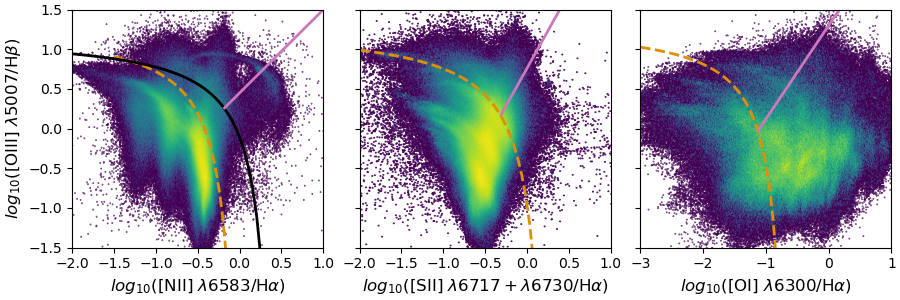

In [18]:
fig = lvm.plot_multi_bpt()

In [19]:
# Get BPT Masks
bpt_masks = lvm.get_bpt_masks(nii = True, sii = True, oi = True)
bpt_masks.keys()

dict_keys(['sf', 'comp', 'agn', 'seyfert', 'liner', 'invalid', 'ambiguous'])

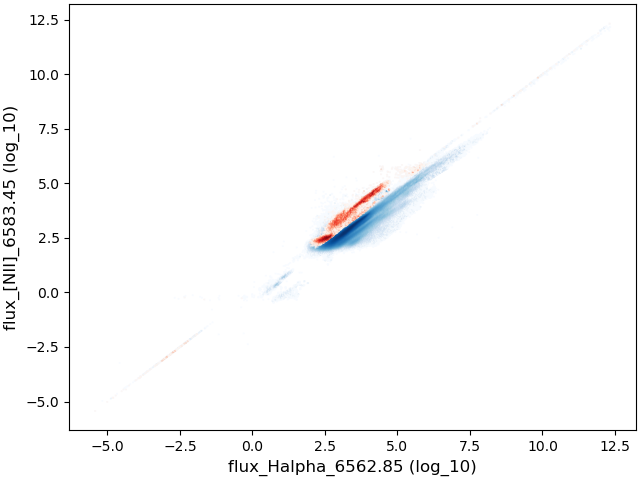

In [20]:

fig = lvm.plot_histogram("flux_Halpha_6562.85", 
                          "flux_[NII]_6583.45",
                         data_mask = flux_mask, 
                         snr_cut = 5, 
                         log_scale = [True, True], 
                         cmap = "Blues", 
                         alpha = 1,
                        )

# plot only LINER points based on [NII] BPT diagram
fig = lvm.plot_histogram("flux_Halpha_6562.85", 
                          "flux_[NII]_6583.45",
                         data_mask = bpt_masks["liner"]["nii"] & flux_mask, 
                         snr_cut = 5, 
                         log_scale = [True, True], 
                         cmap = "Reds", alpha = 0.7,
                         fig = fig, 
                         ax = fig.axes[0])

## Intensity Maps

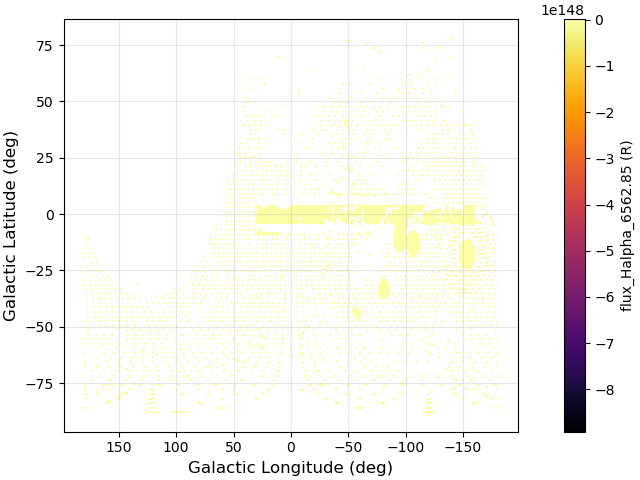

In [21]:

# Plot everything in Galactic Coordinates (quite slow...)
fig = lvm.intensity_map("flux_Halpha_6562.85")

Default scaling isn't good.. can use percentile clipping or set manually. 

Can also plot only specific sections of the sky....

Plotting 798633 points...


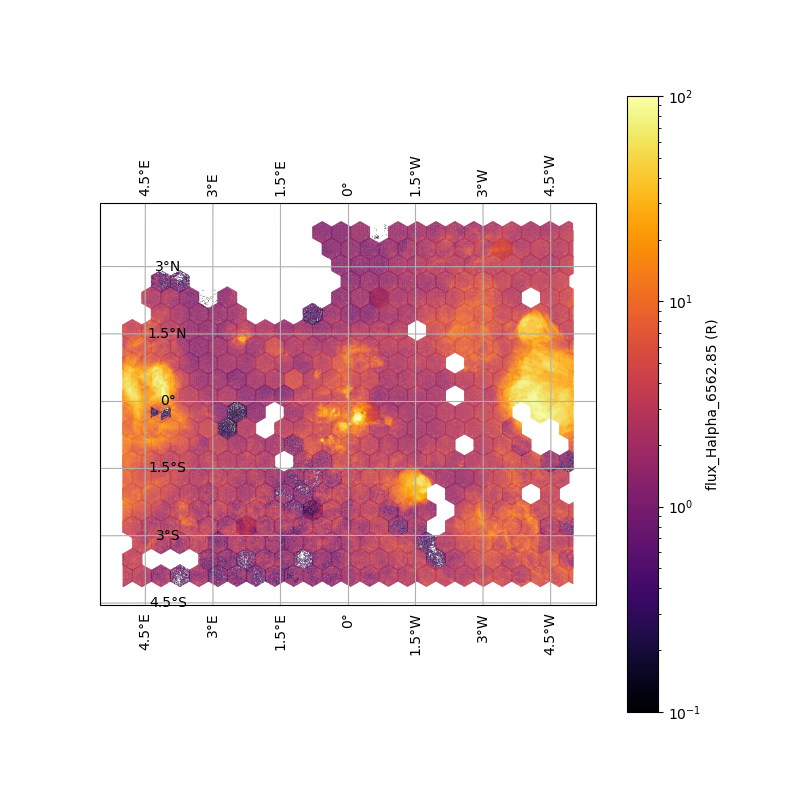

In [22]:
bounds = [-5,5,-5,5]*u.deg

fig = plt.figure(figsize = (8,8))
# Can use cartopy for map projections
ax = fig.add_subplot(111, projection = ccrs.Stereographic())


fig = lvm.intensity_map("flux_Halpha_6562.85",
                        verbose = True, 
                        bounds = bounds,
                        norm = LogNorm(vmin=1e-1,
                                              vmax = 1e2), 
                        aspect = "equal", 
                        fig = fig, 
                        ax = ax,
                        s_factor = 10, # changes scaling of points by factor of 10 larger than initial guess
                       )

### Sky Sections

In [23]:
bounds = [-25,-22,-5,1]*u.deg
lvm_sec = lvm.sky_section(bounds = bounds)

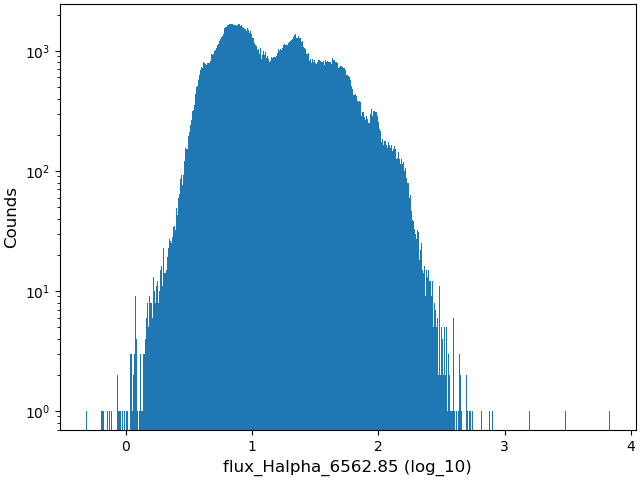

In [24]:
fig= lvm_sec.plot_histogram("flux_Halpha_6562.85", log_scale = True, bins = 500, rayleigh=True)
fig.axes[0].set_yscale("log")

Plotting 173748 points...


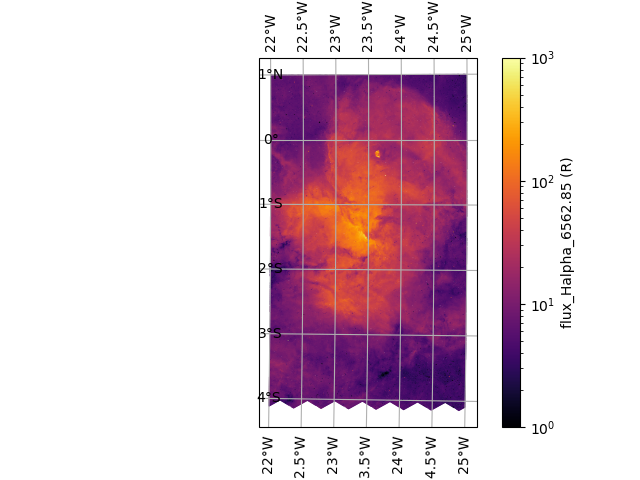

In [25]:
fig=  plt.figure()
ax = fig.add_subplot(111, projection = ccrs.Stereographic())
fig = lvm_sec.intensity_map("flux_Halpha_6562.85",
                        verbose = True, 
                        bounds = bounds,
                        norm = LogNorm(vmin=1e0,
                                              vmax = 1e3), # Can make histogram to help with scaling
                        aspect = "equal", 
                        ax = ax, 
                        fig= fig
                       )

Plotting smooth map of region...


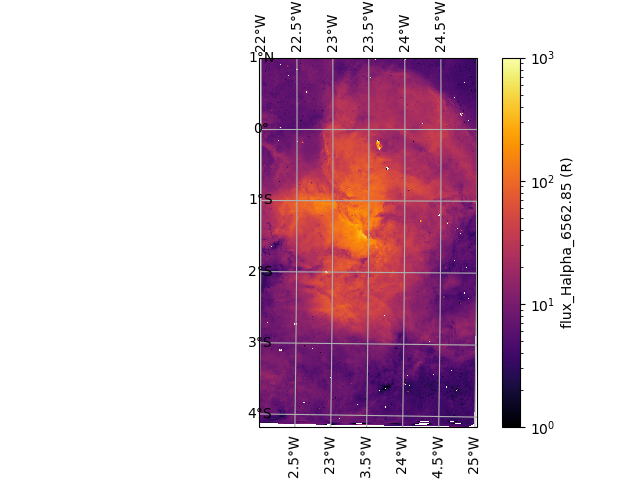

In [26]:
fig=  plt.figure()
ax = fig.add_subplot(111, projection = ccrs.Stereographic())
fig = lvm_sec.intensity_map("flux_Halpha_6562.85",
                        verbose = True, 
                        bounds = bounds,
                        norm = LogNorm(vmin=1e0,
                                              vmax = 1e3), # Can make histogram to help with scaling
                        aspect = "equal", 
                        ax = ax, 
                        fig= fig,
                            smooth = True
                       )

### Plot Custom data on sky maps

In [27]:
# Get distance from BPT Composite Line:
bpt_dist_nii = lvm_sec.get_bpt_sf_curve_distance(nii = True)

/home/dk/repos/dk_lvm_tools/dk_lvm_tools/dapTableMixin.py:536: RuntimeWarning: overflow encountered in cast
  dist_matrix = cdist(data_points.astype(np.float16), curve_points.astype(np.float16))


Plotting 173748 points...


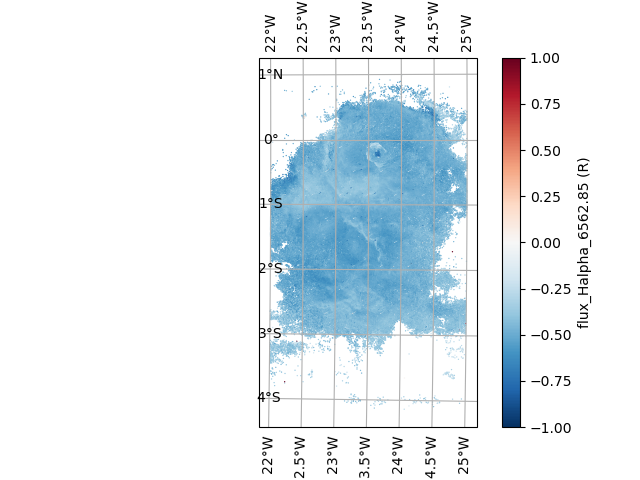

In [30]:
fig=  plt.figure()
ax = fig.add_subplot(111, projection = ccrs.Stereographic())
fig = lvm_sec.intensity_map(bpt_dist_nii["nii"],
                        verbose = True, 
                        bounds = bounds,
                        norm = Normalize(-1,1), # Can make histogram to help with scaling
                        aspect = "equal", 
                        ax = ax, 
                        fig= fig,
                            cmap = "RdBu_r",
                       )